# Data Analysis

## 1. Business Problem

Zomato is a food delivery and restaurant discovery platform. This analysis 
aims to explore the dataset to understand restaurant ratings, pricing, 
cuisines, and customer preferences — and to answer questions such as:

- Which types of restaurants get the best ratings?
- Does online ordering or table booking affect ratings?
- Which localities have the highest concentration of restaurants?
- What price range do most restaurants fall into?

## 2. Import Libraries

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [7]:
import pandas as pd

df = pd.read_csv("../data/Zomato-data-.csv")

df.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet


In [9]:
df.shape

(148, 7)

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   name                         148 non-null    str  
 1   online_order                 148 non-null    str  
 2   book_table                   148 non-null    str  
 3   rate                         148 non-null    str  
 4   votes                        148 non-null    int64
 5   approx_cost(for two people)  148 non-null    int64
 6   listed_in(type)              148 non-null    str  
dtypes: int64(2), str(5)
memory usage: 8.2 KB


In [11]:
df.isnull().sum()

name                           0
online_order                   0
book_table                     0
rate                           0
votes                          0
approx_cost(for two people)    0
listed_in(type)                0
dtype: int64

In [12]:
df.columns

Index(['name', 'online_order', 'book_table', 'rate', 'votes',
       'approx_cost(for two people)', 'listed_in(type)'],
      dtype='str')

In [16]:
def handlerate(value):
    value = str(value).split('/')[0]
    return float(value)
df['rate'] = df['rate'].apply(handlerate)

In [17]:
df.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet


In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   name                         148 non-null    str    
 1   online_order                 148 non-null    str    
 2   book_table                   148 non-null    str    
 3   rate                         148 non-null    float64
 4   votes                        148 non-null    int64  
 5   approx_cost(for two people)  148 non-null    int64  
 6   listed_in(type)              148 non-null    str    
dtypes: float64(1), int64(2), str(4)
memory usage: 8.2 KB


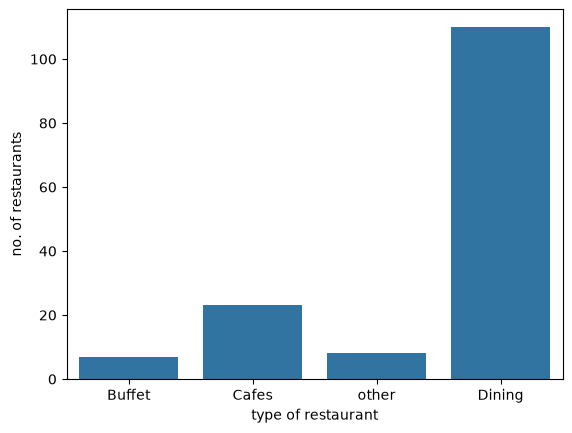

In [21]:
sns.countplot(x=df['listed_in(type)'])
plt.xlabel("type of restaurant")
plt.ylabel("no. of restaurants")
plt.show()

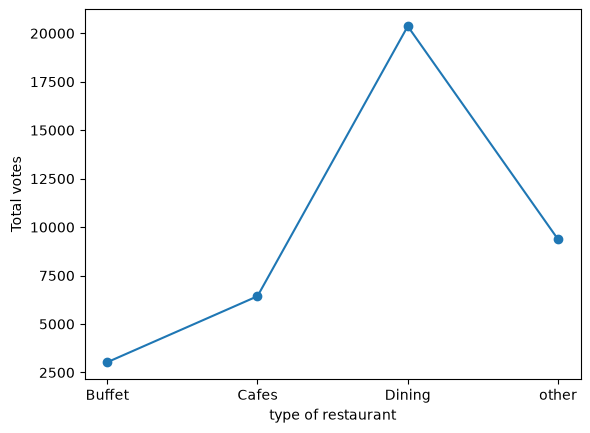

In [25]:
grouped_data = df.groupby('listed_in(type)')['votes'].sum()
result = pd.DataFrame({'votes' : grouped_data})
plt.plot(result, marker = 'o')
plt.xlabel("type of restaurant")
plt.ylabel("Total votes")
plt.show()

In [26]:
max_votes = df['votes'].max()
restaurant_with_max_votes = df.loc[
    df['votes'] == max_votes,
    'name'
]
print("Restaurant with maximum votes:")
print(restaurant_with_max_votes)

Restaurant with maximum votes:
38    Empire Restaurant
Name: name, dtype: str


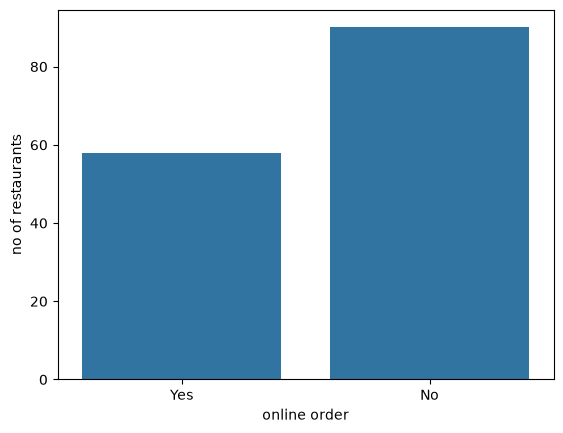

In [27]:
sns.countplot(x=df['online_order'])
plt.xlabel("online order")
plt.ylabel("no of restaurants")
plt.show()

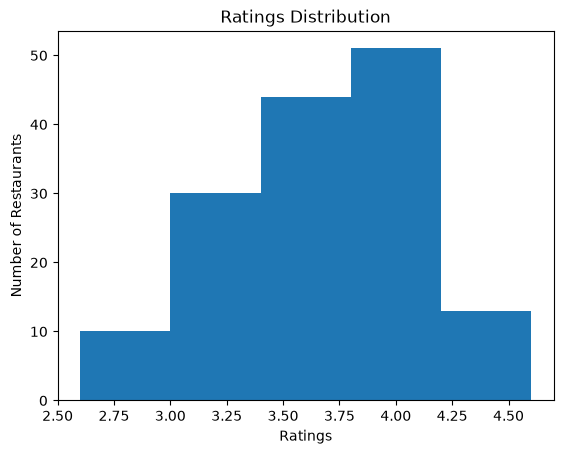

In [28]:
plt.hist(df['rate'], bins=5)

plt.title("Ratings Distribution")
plt.xlabel("Ratings")
plt.ylabel("Number of Restaurants")

plt.show()

In [29]:
df.columns

Index(['name', 'online_order', 'book_table', 'rate', 'votes',
       'approx_cost(for two people)', 'listed_in(type)'],
      dtype='str')

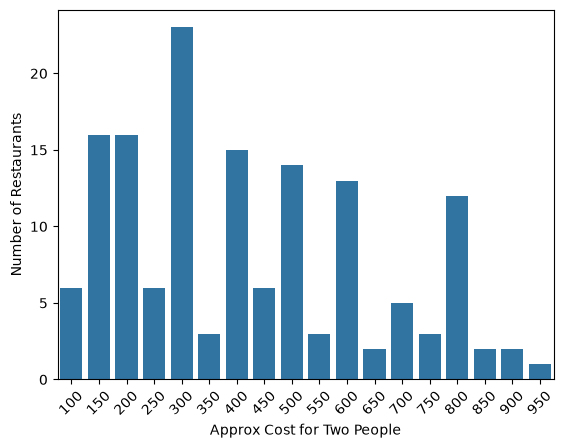

In [30]:
sns.countplot(x=df['approx_cost(for two people)'])

plt.xlabel("Approx Cost for Two People")
plt.ylabel("Number of Restaurants")

plt.xticks(rotation=45)

plt.show()

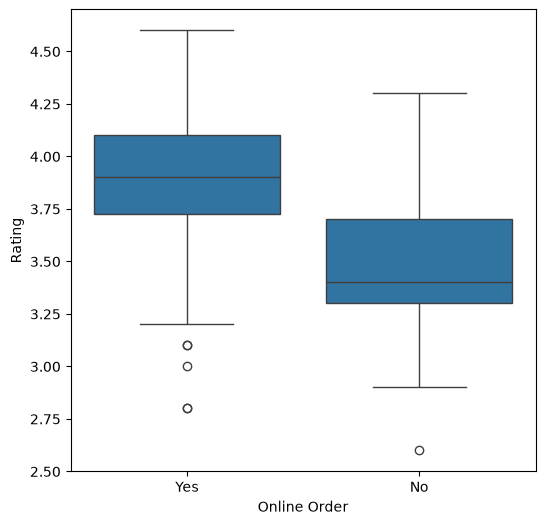

In [31]:
plt.figure(figsize=(6,6))

sns.boxplot(
    x='online_order',
    y='rate',
    data=df
)

plt.xlabel("Online Order")
plt.ylabel("Rating")

plt.show()

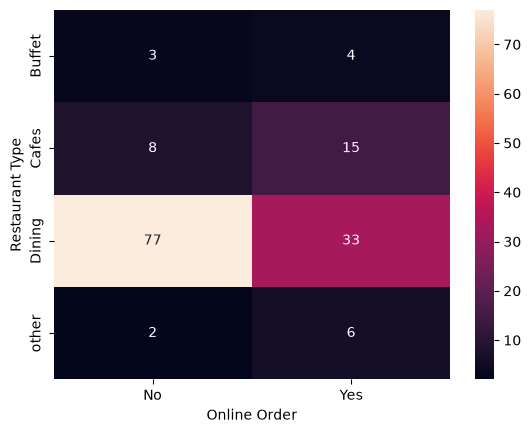

In [32]:
pivot_table = df.pivot_table(
    index='listed_in(type)',
    columns='online_order',
    aggfunc='size',
    fill_value=0
)

sns.heatmap(
    pivot_table,
    annot=True,
    fmt='d'
)

plt.xlabel("Online Order")
plt.ylabel("Restaurant Type")

plt.show()

In [35]:
df.columns

Index(['name', 'online_order', 'book_table', 'rate', 'votes',
       'approx_cost(for two people)', 'listed_in(type)'],
      dtype='str')

In [36]:
df = df.rename(columns={
    "approx_cost(for two people)": "approx_cost",
    "listed_in(type)": "restaurant_type"
})

df.to_csv("cleaned_zomato.csv", index=False)

In [37]:
df.columns

Index(['name', 'online_order', 'book_table', 'rate', 'votes', 'approx_cost',
       'restaurant_type'],
      dtype='str')